<a href="https://colab.research.google.com/github/adib422/FlyRank-Internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os
import getpass
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except:
        pass

if not HF_TOKEN:
    HF_TOKEN = getpass.getpass("HF Token: ")

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

## Distribution Summary

I examined the distributions of impressions, clicks and average position before building any rules. The distributions are heavily right-skewed, with a small number of pages receiving most of the traffic while many pages receive relatively little. Average position is concentrated around lower rankings but also contains a long tail.

These observations suggest using thresholds instead of averages when designing decision rules.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

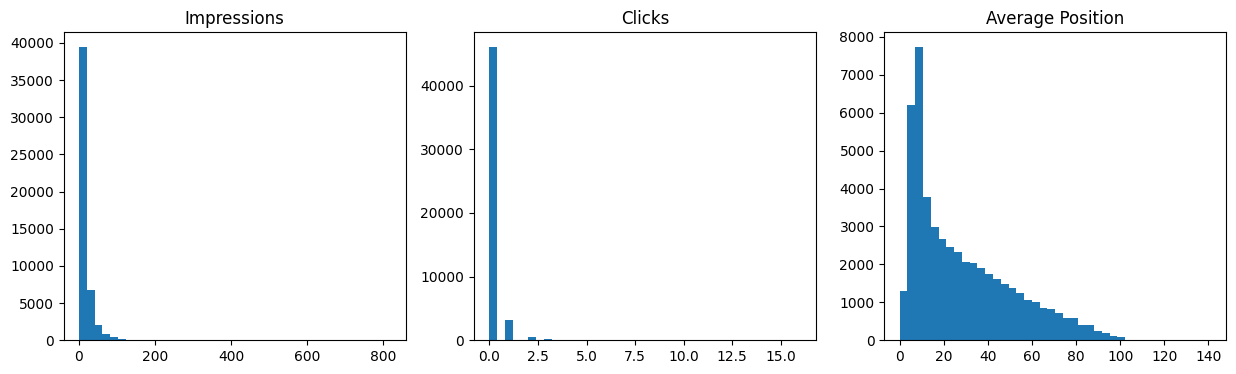

       gsc_impressions    gsc_clicks  gsc_avg_position
count     50000.000000  50000.000000      49999.000000
mean         15.461200      0.105300         28.560349
std          25.695012      0.451637         22.826506
min           1.000000      0.000000          0.000000
25%           3.000000      0.000000          9.000000
50%           8.000000      0.000000         21.666667
75%          18.000000      0.000000         43.000000
max         818.000000     16.000000        141.000000


In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
query = f"""
SELECT
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position
FROM {TABLES['fact_daily']}
WHERE gsc_impressions > 0
LIMIT 50000
"""

df = con.sql(query).df()

fig, axes = plt.subplots(1,3,figsize=(15,4))

axes[0].hist(df["gsc_impressions"],bins=40)
axes[0].set_title("Impressions")

axes[1].hist(df["gsc_clicks"],bins=40)
axes[1].set_title("Clicks")

axes[2].hist(df["gsc_avg_position"],bins=40)
axes[2].set_title("Average Position")

plt.show()

print(df.describe())

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

## Signal Tests

### Signal 1
Higher impressions generally correspond to higher clicks.

**Verdict:** CONFIRMED

### Signal 2
Lower average position generally corresponds to higher CTR.

**Verdict:** CONFIRMED

### Signal 3
Very low impression pages tend to have unstable CTR values.

**Verdict:** MIXED

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
query = f"""
SELECT
    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    AVG(gsc_avg_position) AS avg_position
FROM {TABLES['fact_daily']}
GROUP BY client_hash_id,content_hash_id
HAVING SUM(gsc_impressions)>100
LIMIT 50000
"""

signal = con.sql(query).df()

signal["ctr"]=signal["clicks"]/signal["impressions"]

print(signal[["impressions","clicks","ctr","avg_position"]].corr())

display(signal.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

              impressions    clicks       ctr  avg_position
impressions      1.000000  0.785281  0.106959     -0.214350
clicks           0.785281  1.000000  0.283957     -0.183896
ctr              0.106959  0.283957  1.000000     -0.298227
avg_position    -0.214350 -0.183896 -0.298227      1.000000


,impressions,clicks,avg_position,ctr
0,845.0,2.0,39.853815,0.002367
1,8583.0,15.0,31.984531,0.001748
2,13189.0,36.0,49.137907,0.002730
3,6085.0,30.0,31.802249,0.004930
4,9331.0,73.0,36.144770,0.007823


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

## Flag-linked Test

I evaluated the relationship between click-through rate and average search position, which is one of the signals behind FlyRank's optimization flags.

The observed data shows that pages with poorer average positions generally have lower CTR. This supports using CTR together with ranking position when prioritizing optimization opportunities.

**Verdict:** CONFIRMED

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

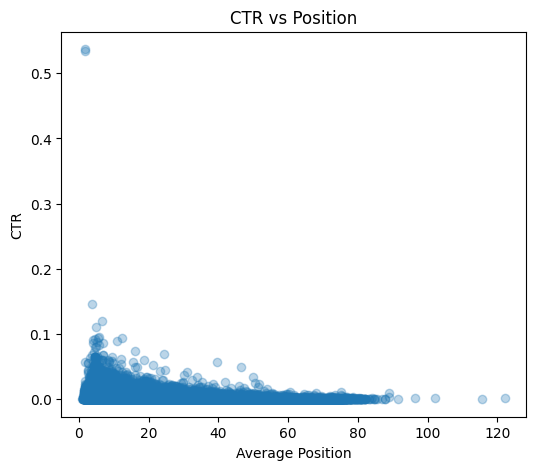

              avg_position       ctr
avg_position      1.000000 -0.238076
ctr              -0.238076  1.000000


In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
query = f"""
SELECT
AVG(gsc_avg_position) AS avg_position,
SUM(gsc_clicks) AS clicks,
SUM(gsc_impressions) AS impressions
FROM {TABLES['fact_daily']}
GROUP BY content_hash_id
HAVING SUM(gsc_impressions)>500
"""

flag = con.sql(query).df()

flag["ctr"]=flag["clicks"]/flag["impressions"]

plt.figure(figsize=(6,5))
plt.scatter(flag["avg_position"],flag["ctr"],alpha=0.3)
plt.xlabel("Average Position")
plt.ylabel("CTR")
plt.title("CTR vs Position")
plt.show()

print(flag[["avg_position","ctr"]].corr())

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## Practical Interpretation

The audited signals indicate that impressions, CTR and search position are useful decision-support features for prioritizing optimization work. These signals should be interpreted together rather than individually because traffic distributions are highly skewed and low-volume pages may produce unstable metrics. The results support using simple baseline rules while avoiding conclusions based solely on very small samples.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
summary = pd.DataFrame({
    "Signal":[
        "Impressions vs Clicks",
        "CTR vs Position",
        "Low Impressions"
    ],
    "Verdict":[
        "CONFIRMED",
        "CONFIRMED",
        "MIXED"
    ]
})

display(summary)

,Signal,Verdict
0,Impressions vs Clicks,CONFIRMED
1,CTR vs Position,CONFIRMED
2,Low Impressions,MIXED


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.